# Steady-vault sizing

This notebook implements NB13 from `steady-vault-plan-01.md`. The parent is
frozen at NB12's P1+D1 selection for each date and universe. It compares three
requested-dollar rules:

* **S0**: equal weight across the selected D1 basket;
* **S1**: inverse observed downside, with a 5% annualised downside floor; and
* **S2**: inverse floored downside multiplied by capped annualised growth,
  where growth is capped at 30% for sizing.

The main arms retain clipped dollars as cash. `S0_redistributed` is the one
control that redistributes equal-weight capacity after a cap binds, so the
effect of sizing can be separated from the effect of leaving capacity idle.
All arms use the same causal NB12 rows, NAV forward-fill for valuation, two-day
execution cadence, 20% individual equity cap, 33% TVL capacity cap and no
invented slippage, liquidation costs or blanket fees. The current A0b
allowlist and full research panel are both reported. Results are historical
diagnostics, not evidence that a risk estimate is a future guarantee.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
NB12 = PROJECT_DIR / "_artifacts-downside-stress"
OUT = PROJECT_DIR / "_artifacts-steady-vault-sizing"
OUT.mkdir(exist_ok=True)

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
INITIAL_CASH = 150_000.0
TARGET_DEPLOYMENT = 0.98
MAX_WEIGHT = 0.20
MAX_TVL_FRACTION = 0.33
EXECUTION_EVERY_DAYS = 2
DOWNside_FLOOR = 0.05
GROWTH_CAP = 0.30

OBS = pd.read_parquet(REWRITE / "observations.parquet")
OBS["address"] = OBS.address.astype(str).str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
OBS = OBS[OBS.is_fresh & OBS.share_price.gt(0)].sort_values(["address", "timestamp"])
METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.astype(str).str.lower()
METADATA = METADATA.drop_duplicates("address").set_index("address")

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
universe_json = json.loads(UNIVERSE_CACHE.read_text())
universe_items = universe_json.get("vaults", universe_json) if isinstance(universe_json, dict) else universe_json
A0B_ALLOWLIST = {str(item["address"]).lower() for item in universe_items if "address" in item}
A0B_ALLOWLIST.discard("0x5290ab34acb59cfe1371baa5782eba14433d308f")

SIGNAL_COLUMNS = ["date", "address", "selected", "selection_rank", "qualified", "tvl_current", "estimated_net_growth", "annualised_downside", "available_history_days", "last_interval_days", "stress_triggered", "drawdown_observed", "volatility_observed", "parent_qualified", "parent_selection_order"]
SELECTIONS = {}
for universe_name, addresses in {"full_panel": set(), "a0b_allowlist": A0B_ALLOWLIST}.items():
    path = NB12 / f"selection-{universe_name}-D1.parquet"
    frame = pd.read_parquet(path)
    frame["date"] = pd.to_datetime(frame.date).dt.normalize()
    frame["address"] = frame.address.astype(str).str.lower()
    if universe_name == "full_panel":
        addresses = set(frame.address.unique())
    frame = frame[[column for column in SIGNAL_COLUMNS if column in frame.columns]].copy()
    SELECTIONS[universe_name] = frame[frame.date.between(PERIODS["full"][0], PERIODS["full"][1])].copy()

print({"observations": OBS.shape, "universes": {name: int(frame.address.nunique()) for name, frame in SELECTIONS.items()}, "selected_d1_rows": {name: int(frame.selected.sum()) for name, frame in SELECTIONS.items()}})


{'observations': (487738, 9), 'universes': {'full_panel': 529, 'a0b_allowlist': 335}, 'selected_d1_rows': {'full_panel': 2874, 'a0b_allowlist': 2192}}


## Frozen parent and causal sizing inputs

NB12 has already applied the frozen P1 parent and D1 observed-drawdown screen.
This notebook loads its saved selection rows and never loads forward labels.
`estimated_net_growth` and `annualised_downside` are formation-history values
available at the decision date. The 5% floor prevents a measured zero or tiny
downside estimate from receiving an unbounded weight. Every selected row has a
finite growth and downside estimate in the tested periods; if a future input
does not, the sizing code records it and assigns no weighted score rather than
claiming missing risk is zero.

The A0b allowlist is a current retrospective snapshot. The full-panel result
is therefore a required universe sensitivity, not an unbiased replacement for
the allowlist.


In [2]:
def finite(value):
    return pd.notna(value) and np.isfinite(float(value))


def target_scores(chosen, arm):
    output = chosen.copy()
    downside = pd.to_numeric(output.annualised_downside, errors="coerce")
    growth = pd.to_numeric(output.estimated_net_growth, errors="coerce")
    floored_downside = downside.clip(lower=DOWNside_FLOOR)
    if arm in ("S0", "S0_redistributed"):
        raw = pd.Series(1.0, index=output.index)
    elif arm == "S1":
        raw = 1.0 / floored_downside
    elif arm == "S2":
        raw = (growth.clip(lower=0.0, upper=GROWTH_CAP) / GROWTH_CAP) / floored_downside
    else:
        raise ValueError(arm)
    raw = raw.where(downside.notna() & growth.notna(), 0.0)
    output["downside_floor"] = floored_downside
    output["raw_sizing_score"] = raw.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    output["sizing_input_missing"] = downside.isna() | growth.isna()
    return output


def requested_weights(chosen, arm):
    scored = target_scores(chosen, arm)
    scores = scored.raw_sizing_score.clip(lower=0.0)
    if scores.sum() <= 0:
        weights = pd.Series(0.0, index=scored.index)
    else:
        weights = TARGET_DEPLOYMENT * scores / scores.sum()
    scored["requested_weight"] = weights
    return scored


SELECTION_SUMMARY = []
for universe_name, frame in SELECTIONS.items():
    selected = frame[frame.selected.fillna(False)]
    SELECTION_SUMMARY.append({"universe": universe_name, "rows": len(frame), "dates": int(frame.date.nunique()), "selected_rows": len(selected), "selected_dates": int(selected.date.nunique()), "selected_addresses": int(selected.address.nunique()), "missing_downside": int(selected.annualised_downside.isna().sum()), "missing_growth": int(selected.estimated_net_growth.isna().sum()), "median_downside": float(selected.annualised_downside.median()), "median_growth": float(selected.estimated_net_growth.median())})
selection_summary = pd.DataFrame(SELECTION_SUMMARY)
selection_summary.to_csv(OUT / "frozen-parent-selection-summary.csv", index=False)
display(selection_summary)


,universe,rows,dates,selected_rows,selected_dates,selected_addresses,missing_downside,missing_growth,median_downside,median_growth
0,full_panel,87081,365,2874,226,111,0,0,0.054312,0.474528
1,a0b_allowlist,52219,365,2192,223,73,0,0,0.054334,0.460686


## NAV replay and cap handling

Marks are carried forward only for valuation from fresh raw NAV observations.
Eligibility and sizing inputs remain frozen point-in-time rows. At each
execution date, selected vaults receive the requested dollar allocation. Main
arms clip it to both the individual equity cap and TVL cap and keep the
unallocated amount in cash. The redistribution control repeatedly allocates
equal weight to names with remaining cap until either the 98% deployment target
or all capacity is exhausted. This is deliberately the only arm that
redistributes after clipping.

The simulator retains a currently held explicitly blocked address and lets it
consume capital. It does not fabricate an exit mark, fee or immediate
liquidity. The event attribution fields identify the largest daily portfolio
move and the address contributing the largest dollar move on that day; they
are descriptive attribution rather than a tradable counterfactual.


In [3]:
def build_daily_marks(observations, dates):
    marks = observations.assign(calendar_date=observations.timestamp.dt.normalize()).groupby(["calendar_date", "address"]).share_price.last().unstack("address")
    index = marks.index.union(dates).sort_values()
    return marks.reindex(index).sort_index().ffill().reindex(dates)


BLOCKED = set()
if "redemption_closed_reason" in METADATA:
    values = METADATA.redemption_closed_reason.astype("string")
    BLOCKED = set(METADATA.index[values.notna() & values.str.strip().ne("")])


def capped_allocations(scored, equity, arm, tvl_by_address, held_blocked):
    if scored.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    caps = pd.Series({address: min(equity * MAX_WEIGHT, max(float(tvl_by_address.get(address, 0.0)), 0.0) * MAX_TVL_FRACTION) for address in scored.address}, dtype=float)
    weights = scored.set_index("address").requested_weight.astype(float)
    desired = equity * weights
    if arm != "S0_redistributed":
        return desired.clip(lower=0.0).combine(caps, min), caps
    # Equal-weight water-fill control. The only names eligible for the
    # redistribution are selected names with a positive available cap.
    remaining = equity * TARGET_DEPLOYMENT
    accepted = pd.Series(0.0, index=caps.index)
    active = set(caps.index[caps.gt(0)])
    while active and remaining > 1e-9:
        proposed = remaining / len(active)
        bound = [address for address in active if caps[address] - accepted[address] < proposed]
        if not bound:
            accepted.loc[list(active)] += proposed
            remaining = 0.0
            break
        for address in bound:
            amount = max(caps[address] - accepted[address], 0.0)
            accepted[address] += amount
            remaining -= amount
            active.remove(address)
    return accepted, caps


def replay(selection, start, end, universe_name, arm):
    dates = pd.date_range(start, end, freq="D")
    marks = build_daily_marks(OBS, dates)
    execution_dates = set(dates[::EXECUTION_EVERY_DAYS])
    rows, target_rows = [], []
    cash = INITIAL_CASH
    units = {}
    last_prices = {}
    previous_values = {}
    for date in dates:
        day_prices = marks.loc[date] if date in marks.index else pd.Series(dtype=float)
        for address, price in day_prices.dropna().items():
            last_prices[address] = float(price)
        marked = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        equity = cash + sum(marked.values())
        target = dict(marked)
        turnover = 0.0
        leader_address = None
        leader_gain = 0.0
        # Attribute only the price movement of positions held from the prior
        # valuation.  Rebalance purchases are filled at the current NAV and
        # must not be counted as gains on the execution date.
        if previous_values:
            changes = {address: marked.get(address, 0.0) - previous_values.get(address, 0.0) for address in set(marked) | set(previous_values)}
            positive_changes = {address: value for address, value in changes.items() if value > 0}
            if positive_changes:
                leader_address, leader_gain = max(positive_changes.items(), key=lambda pair: pair[1])
        if date in execution_dates:
            day = selection[selection.date.eq(date) & selection.selected.fillna(False)].copy()
            scored = requested_weights(day, arm)
            tvl_by_address = dict(zip(scored.address, pd.to_numeric(scored.tvl_current, errors="coerce").fillna(0.0))) if len(scored) else {}
            accepted, caps = capped_allocations(scored, equity, arm, tvl_by_address, BLOCKED)
            target = {address: value for address, value in marked.items() if address in BLOCKED}
            for item in scored.itertuples(index=False):
                address = item.address
                requested = float(equity * item.requested_weight) if finite(item.requested_weight) else 0.0
                accepted_dollars = float(accepted.get(address, 0.0))
                if address in BLOCKED and address in target:
                    accepted_dollars = float(target[address])
                if address in last_prices and accepted_dollars > 0:
                    target[address] = accepted_dollars
                target_rows.append({"date": date, "universe": universe_name, "arm": arm, "address": address, "selection_rank": item.selection_rank, "requested_weight": item.requested_weight, "requested_dollars": requested, "accepted_dollars": accepted_dollars, "accepted_weight": accepted_dollars / equity if equity else np.nan, "cap_dollars": float(caps.get(address, 0.0)), "cap_binding": accepted_dollars + 1e-8 < requested, "sizing_input_missing": bool(item.sizing_input_missing), "annualised_downside": item.annualised_downside, "downside_floor": item.downside_floor, "estimated_net_growth": item.estimated_net_growth, "tvl_current": item.tvl_current, "accepted_tvl_fraction": accepted_dollars / float(item.tvl_current) if finite(item.tvl_current) and float(item.tvl_current) > 0 else np.nan, "available_history_days": item.available_history_days, "last_interval_days": item.last_interval_days, "blocked": address in BLOCKED})
            cash = max(equity - sum(target.values()), 0.0)
            turnover = float(sum(abs(target.get(address, 0.0) - marked.get(address, 0.0)) for address in set(target) | set(marked)))
            units = {address: value / last_prices[address] for address, value in target.items() if value > 0 and address in last_prices}
            equity = cash + sum(value for address, value in target.items() if address in last_prices)
        invested = max(equity - cash, 0.0)
        weights = pd.Series({address: value / invested for address, value in target.items()}) if invested > 0 else pd.Series(dtype=float)
        current_values = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        rows.append({"date": date, "equity": equity, "cash": cash, "cash_fraction": cash / equity if equity else np.nan, "invested": invested, "n_positions": len(target), "effective_positions": float(1 / weights.pow(2).sum()) if len(weights) and weights.pow(2).sum() > 0 else 0.0, "max_position_weight": float(weights.max()) if len(weights) else 0.0, "turnover": turnover, "execution_date": date in execution_dates, "leader_address": leader_address, "leader_gain": leader_gain, "universe": universe_name, "arm": arm})
        previous_values = current_values
    curve = pd.DataFrame(rows)
    curve["return"] = curve.equity.pct_change()
    curve["invested_return"] = curve.equity.diff() / curve.invested.shift(1).replace(0.0, np.nan)
    curve["drawdown"] = curve.equity / curve.equity.cummax() - 1
    return curve, pd.DataFrame(target_rows)


def metrics(curve, periods_per_year=365.0):
    if curve.empty:
        return {}
    returns = curve["return"].dropna()
    invested_returns = curve["invested_return"].replace([np.inf, -np.inf], np.nan).dropna()
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    std = returns.std(ddof=1)
    invested_std = invested_returns.std(ddof=1)
    return {"start": curve.date.iloc[0], "end": curve.date.iloc[-1], "final_equity": float(curve.equity.iloc[-1]), "cagr": float((curve.equity.iloc[-1] / curve.equity.iloc[0]) ** (365.0 / span_days) - 1), "volatility": float(std * math.sqrt(periods_per_year)) if finite(std) else np.nan, "sharpe": float(returns.mean() / std * math.sqrt(periods_per_year)) if finite(std) and std > 0 else np.nan, "invested_volatility": float(invested_std * math.sqrt(periods_per_year)) if finite(invested_std) else np.nan, "invested_sharpe": float(invested_returns.mean() / invested_std * math.sqrt(periods_per_year)) if finite(invested_std) and invested_std > 0 else np.nan, "max_drawdown": float(curve.drawdown.min()), "ulcer": float(np.sqrt(np.mean(curve.drawdown.pow(2)))), "mean_cash_fraction": float(curve.cash_fraction.mean()), "mean_invested_fraction": float((curve.invested / curve.equity).mean()), "mean_positions": float(curve.n_positions.mean()), "mean_effective_positions": float(curve.effective_positions.mean()), "max_observed_position_weight": float(curve.max_position_weight.max()), "mean_turnover": float(curve.turnover.mean()), "leader_gain": float(curve.leader_gain.max())}


def weekly_curve(curve):
    source = curve.assign(week=curve.date.dt.to_period("W-SUN").dt.end_time.dt.normalize()).sort_values("date")
    weekly = source.groupby("week", as_index=False).last()
    weekly["return"] = weekly.equity.pct_change()
    # Compound the daily invested returns inside each calendar week.  Using
    # week-end equity divided by week-start invested dollars is wrong when a
    # rebalance deploys cash during the week.
    invested_returns = source.groupby("week")["invested_return"].agg(lambda values: float((1.0 + values.fillna(0.0)).prod() - 1.0))
    weekly["invested_return"] = weekly["week"].map(invested_returns)
    weekly["drawdown"] = weekly.equity / weekly.equity.cummax() - 1
    return weekly


ARMS = ("S0", "S1", "S2", "S0_redistributed")
metric_rows, curves = [], {}
for universe_name, selection in SELECTIONS.items():
    for arm in ARMS:
        for period_name, (start, end) in PERIODS.items():
            curve, targets = replay(selection, start, end, universe_name, arm)
            curves[(universe_name, arm, period_name)] = curve
            curve.to_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet", index=False)
            targets.to_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet", index=False)
            for clock, measured, annualisation in [("daily", curve, 365.0), ("weekly", weekly_curve(curve), 52.0)]:
                metric_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "clock": clock, **metrics(measured, annualisation)})
metrics_table = pd.DataFrame(metric_rows)
metrics_table.to_csv(OUT / "backtest-metrics.csv", index=False)
display(metrics_table.round(4))

# S0 is the sizing-only control.  Its equity path must match NB12's D1
# replay exactly; otherwise a sizing comparison would also compare simulators.
parity_rows = []
for universe_name in SELECTIONS:
    for period_name in PERIODS:
        actual = curves[(universe_name, "S0", period_name)]
        reference = pd.read_parquet(NB12 / f"equity-{universe_name}-D1-{period_name}.parquet")
        if not actual.date.equals(pd.to_datetime(reference.date)):
            raise AssertionError(f"S0/NB12 D1 date mismatch: {universe_name}/{period_name}")
        max_abs_equity_error = float(np.max(np.abs(actual.equity.to_numpy() - reference.equity.to_numpy())))
        np.testing.assert_allclose(actual.equity.to_numpy(), reference.equity.to_numpy(), rtol=1e-10, atol=1e-7)
        parity_rows.append({"universe": universe_name, "period": period_name, "max_abs_equity_error": max_abs_equity_error, "status": "pass"})
parity = pd.DataFrame(parity_rows)
parity.to_csv(OUT / "s0-nb12-d1-parity.csv", index=False)
display(parity)


,universe,arm,period,clock,start,end,final_equity,cagr,volatility,sharpe,...,invested_sharpe,max_drawdown,ulcer,mean_cash_fraction,mean_invested_fraction,mean_positions,mean_effective_positions,max_observed_position_weight,mean_turnover,leader_gain
0,full_panel,S0,hyper_ai,daily,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,...,0.0491,-0.0694,0.0337,0.4047,0.5953,10.7989,9.3151,0.5,18810.0101,2903.5386
1,full_panel,S0,hyper_ai,weekly,2026-01-04,2026-07-08,149775.0407,-0.0030,0.1285,0.0406,...,0.0608,-0.0693,0.0336,0.4038,0.5962,11.0000,9.5818,0.5,16442.4431,522.6707
2,full_panel,S0,full,daily,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,...,0.6579,-0.0694,0.0275,0.5589,0.4411,7.8438,6.8276,0.5,13242.5774,2903.5386
3,full_panel,S0,full,weekly,2025-09-14,2026-09-12,155516.6196,0.0370,0.0955,0.4258,...,0.4467,-0.0693,0.0272,0.5636,0.4364,7.8679,6.8866,0.5,10949.9628,522.6707
4,full_panel,S1,hyper_ai,daily,2026-01-01,2026-07-08,146926.3817,-0.0394,0.0933,-0.3834,...,-0.3859,-0.0809,0.0426,0.3892,0.6108,10.7989,8.3386,0.5,16969.8064,2225.1172
5,full_panel,S1,hyper_ai,weekly,2026-01-04,2026-07-08,146926.3817,-0.0400,0.1240,-0.2591,...,-0.2338,-0.0806,0.0426,0.3889,0.6111,11.0000,8.6646,0.5,15858.1039,470.9292
6,full_panel,S1,full,daily,2025-09-13,2026-09-12,151072.5643,0.0072,0.0690,0.1386,...,0.2354,-0.0809,0.0354,0.5521,0.4479,7.8438,6.2241,0.5,12313.0612,2225.1172
7,full_panel,S1,full,weekly,2025-09-14,2026-09-12,151072.5643,0.0072,0.0906,0.1250,...,0.1671,-0.0806,0.0351,0.5576,0.4424,7.8679,6.3024,0.5,10510.2832,470.9292
8,full_panel,S2,hyper_ai,daily,2026-01-01,2026-07-08,146156.5671,-0.0491,0.1006,-0.4498,...,-0.4548,-0.0876,0.0467,0.3924,0.6076,10.7989,8.2470,0.5,16460.9548,2225.1172
9,full_panel,S2,hyper_ai,weekly,2026-01-04,2026-07-08,146156.5671,-0.0499,0.1349,-0.3025,...,-0.2727,-0.0874,0.0468,0.3914,0.6086,11.0000,8.5651,0.5,15586.2485,493.1276


,universe,period,max_abs_equity_error,status
0,full_panel,hyper_ai,8.731149e-11,pass
1,full_panel,full,1.164153e-10,pass
2,a0b_allowlist,hyper_ai,2.910383e-11,pass
3,a0b_allowlist,full,8.731149e-11,pass


## Cap, concentration and event attribution

These tables make it possible to distinguish lower volatility caused by cash
from lower volatility in the invested basket. The effective position count is
`1 / sum(weight²)` over invested positions. TVL and individual-cap binding are
reported from accepted target dollars; no rebalance is hidden by normalising
the clipped main arms. `invested_volatility` and `invested_sharpe` use the
change in total equity divided by the prior day's invested dollars, so a
rebalance at current NAV does not create a return. The leader-removal values
are a sensitivity that removes the largest daily portfolio return from the
compound path and is not a tradable strategy.


,universe,arm,period,target_rows,cap_binding_rows,cap_binding_fraction,missing_sizing_rows,mean_accepted_tvl_fraction,max_accepted_tvl_fraction,mean_requested_dollars,mean_accepted_dollars
0,full_panel,S0,hyper_ai,1027,462,0.4499,0,0.1945,0.33,11446.1385,8265.3957
1,full_panel,S0,full,1437,664,0.4621,0,0.1990,0.33,11586.7055,8463.3094
2,full_panel,S1,hyper_ai,1027,416,0.4051,0,0.1864,0.33,11265.1804,8341.2135
3,full_panel,S1,full,1437,600,0.4175,0,0.1918,0.33,11379.9103,8436.1306
4,full_panel,S2,hyper_ai,1027,423,0.4119,0,0.1868,0.33,11231.5446,8268.4463
5,full_panel,S2,full,1437,612,0.4259,0,0.1917,0.33,11336.0887,8350.9309
6,full_panel,S0_redistributed,hyper_ai,1027,462,0.4499,0,0.2128,0.33,11446.9096,10618.1846
7,full_panel,S0_redistributed,full,1437,664,0.4621,0,0.2172,0.33,11623.3690,10912.1011
8,a0b_allowlist,S0,hyper_ai,775,406,0.5239,0,0.2221,0.33,14459.4293,8945.8321
9,a0b_allowlist,S0,full,1095,588,0.5370,0,0.2242,0.33,14307.5264,9145.1919


,universe,arm,period,leader_date,leader_daily_return,leader_address,leader_address_gain,leader_removed_final_equity,leader_removed_cagr
0,full_panel,S0,hyper_ai,2026-05-23,0.0235,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,2903.5386,146342.6155,-0.0468
1,full_panel,S0,full,2026-05-23,0.0235,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,2903.5386,151952.6134,0.0131
2,full_panel,S1,hyper_ai,2026-02-06,0.0136,0x9a28b01435ca5c4b39a79ae2c27fce01292a7f39,2225.1172,144960.0894,-0.0642
3,full_panel,S1,full,2026-02-06,0.0136,0x9a28b01435ca5c4b39a79ae2c27fce01292a7f39,2225.1172,149050.7843,-0.0063
4,full_panel,S2,hyper_ai,2026-05-18,0.0137,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,1655.6153,144184.0603,-0.0739
5,full_panel,S2,full,2026-05-18,0.0137,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,1655.6153,148148.8147,-0.0124
6,full_panel,S0_redistributed,hyper_ai,2026-05-23,0.0310,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,3900.2662,146051.0999,-0.0505
7,full_panel,S0_redistributed,full,2026-05-23,0.0310,0xa04cc046c32dc706c65324ae6352d3d78e0c2013,3900.2662,154207.6636,0.0281
8,a0b_allowlist,S0,hyper_ai,2026-02-21,0.0079,0x4dec0a851849056e259128464ef28ce78afa27f6,699.4343,137326.1216,-0.1575
9,a0b_allowlist,S0,full,2026-02-21,0.0079,0x4dec0a851849056e259128464ef28ce78afa27f6,699.4343,137624.9859,-0.0827


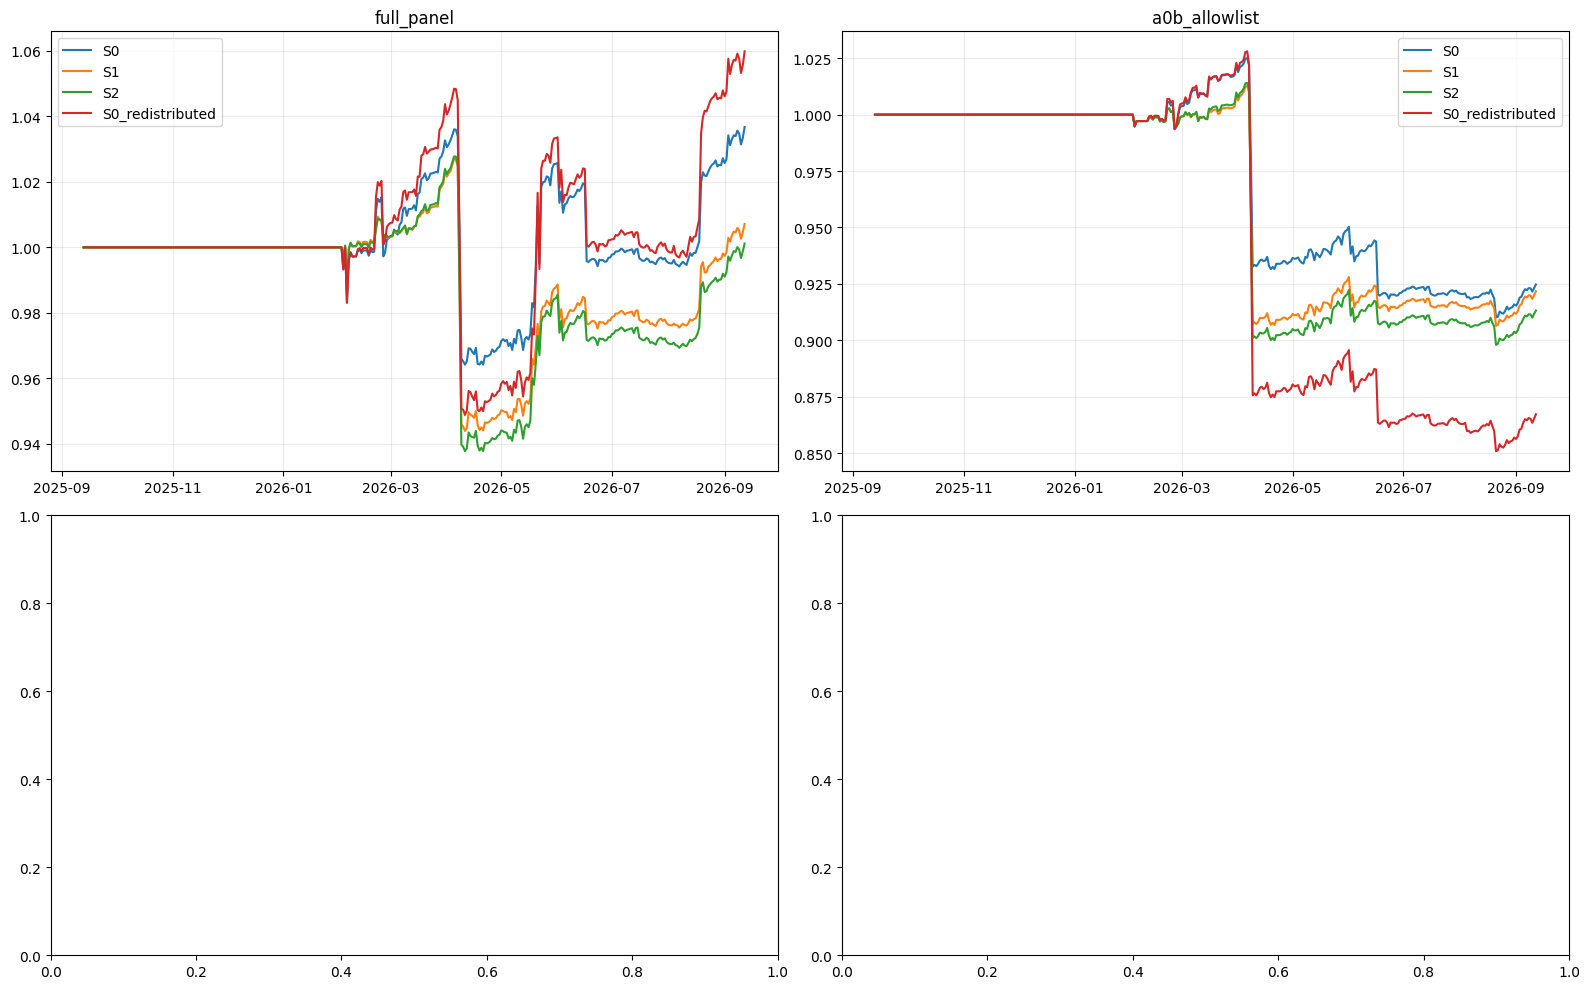

In [4]:
cap_rows, attribution_rows = [], []
for (universe_name, arm, period_name), curve in curves.items():
    targets = pd.read_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet")
    cap_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "target_rows": len(targets), "cap_binding_rows": int(targets.cap_binding.sum()) if len(targets) else 0, "cap_binding_fraction": float(targets.cap_binding.mean()) if len(targets) else np.nan, "missing_sizing_rows": int(targets.sizing_input_missing.sum()) if len(targets) else 0, "mean_accepted_tvl_fraction": float(targets.accepted_tvl_fraction.mean()) if len(targets) else np.nan, "max_accepted_tvl_fraction": float(targets.accepted_tvl_fraction.max()) if len(targets) else np.nan, "mean_requested_dollars": float(targets.requested_dollars.mean()) if len(targets) else np.nan, "mean_accepted_dollars": float(targets.accepted_dollars.mean()) if len(targets) else np.nan})
    returns = curve["return"].dropna()
    if len(returns):
        leader_index = returns.idxmax()
        adjusted = returns.copy()
        adjusted.loc[leader_index] = 0.0
        final_without_leader = float(INITIAL_CASH * (1.0 + adjusted).prod())
        span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
        leader_date = curve.loc[leader_index, "date"]
        leader_row = curve.loc[leader_index]
        attribution_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "leader_date": leader_date, "leader_daily_return": float(returns.loc[leader_index]), "leader_address": leader_row.leader_address, "leader_address_gain": float(leader_row.leader_gain), "leader_removed_final_equity": final_without_leader, "leader_removed_cagr": float((final_without_leader / INITIAL_CASH) ** (365.0 / span_days) - 1)})
cap_summary = pd.DataFrame(cap_rows)
attribution = pd.DataFrame(attribution_rows)
cap_summary.to_csv(OUT / "cap-concentration-summary.csv", index=False)
attribution.to_csv(OUT / "leader-and-best-event-attribution.csv", index=False)
display(cap_summary.round(4))
display(attribution.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
for axis, universe_name in zip(axes.flat, SELECTIONS):
    for arm in ARMS:
        curve = curves[(universe_name, arm, "full")]
        axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=arm)
    axis.set_title(universe_name)
    axis.grid(alpha=.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "steady-vault-sizing-equity-curves.png", dpi=130)
plt.show()


## Results and limitations

S0, S1 and S2 share the same P1+D1 parent. A higher Sharpe with materially
 more cash is not evidence that vault selection improved. Compare the invested
basket metrics, cash fraction, effective positions and cap summaries together.
The full-panel sensitivity is required because the A0b allowlist is a
retrospective snapshot. Downside estimates are based on observed NAV intervals
and can understate unobserved intraperiod stress, especially for sparse marks.
These historical replays do not establish a prospective 20% CAGR or Sharpe.


In [5]:
report = {
    "notebook": "13-research-steady-vault-sizing.ipynb",
    "parent": "NB12 P1+D1 frozen selection; selection files are consumed without forward labels",
    "arms": list(ARMS),
    "sizing": {"S0": "equal weights; cap remainder is cash", "S1": "inverse annualised downside with 5% floor; cap remainder is cash", "S2": "inverse floored downside times min(growth, 30%)/30%; cap remainder is cash", "S0_redistributed": "equal-weight water-fill redistribution after capacity caps"},
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "starting_cash": INITIAL_CASH,
    "target_deployment": TARGET_DEPLOYMENT,
    "individual_equity_cap": MAX_WEIGHT,
    "tvl_cap_fraction": MAX_TVL_FRACTION,
    "downside_floor": DOWNside_FLOOR,
    "growth_cap": GROWTH_CAP,
    "execution_every_days": EXECUTION_EVERY_DAYS,
    "fees": "none added; observable NAV share prices are the accounting input",
    "marks": "fresh raw share-price observations forward-filled for valuation only",
    "missing_sizing_policy": "missing growth or downside receives zero weighted score and is counted; no missing-risk zero imputation",
    "allowlist_warning": "A0b allowlist is a retrospective current snapshot; full panel is a required sensitivity",
    "metrics": metrics_table.to_dict(orient="records"),
    "s0_nb12_d1_parity": parity.to_dict(orient="records"),
    "selection_summary": selection_summary.to_dict(orient="records"),
}
(OUT / "nb13-report.json").write_text(json.dumps(report, indent=2, default=str))
display(pd.DataFrame(report["metrics"]).round(4))


,universe,arm,period,clock,start,end,final_equity,cagr,volatility,sharpe,...,invested_sharpe,max_drawdown,ulcer,mean_cash_fraction,mean_invested_fraction,mean_positions,mean_effective_positions,max_observed_position_weight,mean_turnover,leader_gain
0,full_panel,S0,hyper_ai,daily,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,...,0.0491,-0.0694,0.0337,0.4047,0.5953,10.7989,9.3151,0.5,18810.0101,2903.5386
1,full_panel,S0,hyper_ai,weekly,2026-01-04,2026-07-08,149775.0407,-0.0030,0.1285,0.0406,...,0.0608,-0.0693,0.0336,0.4038,0.5962,11.0000,9.5818,0.5,16442.4431,522.6707
2,full_panel,S0,full,daily,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,...,0.6579,-0.0694,0.0275,0.5589,0.4411,7.8438,6.8276,0.5,13242.5774,2903.5386
3,full_panel,S0,full,weekly,2025-09-14,2026-09-12,155516.6196,0.0370,0.0955,0.4258,...,0.4467,-0.0693,0.0272,0.5636,0.4364,7.8679,6.8866,0.5,10949.9628,522.6707
4,full_panel,S1,hyper_ai,daily,2026-01-01,2026-07-08,146926.3817,-0.0394,0.0933,-0.3834,...,-0.3859,-0.0809,0.0426,0.3892,0.6108,10.7989,8.3386,0.5,16969.8064,2225.1172
5,full_panel,S1,hyper_ai,weekly,2026-01-04,2026-07-08,146926.3817,-0.0400,0.1240,-0.2591,...,-0.2338,-0.0806,0.0426,0.3889,0.6111,11.0000,8.6646,0.5,15858.1039,470.9292
6,full_panel,S1,full,daily,2025-09-13,2026-09-12,151072.5643,0.0072,0.0690,0.1386,...,0.2354,-0.0809,0.0354,0.5521,0.4479,7.8438,6.2241,0.5,12313.0612,2225.1172
7,full_panel,S1,full,weekly,2025-09-14,2026-09-12,151072.5643,0.0072,0.0906,0.1250,...,0.1671,-0.0806,0.0351,0.5576,0.4424,7.8679,6.3024,0.5,10510.2832,470.9292
8,full_panel,S2,hyper_ai,daily,2026-01-01,2026-07-08,146156.5671,-0.0491,0.1006,-0.4498,...,-0.4548,-0.0876,0.0467,0.3924,0.6076,10.7989,8.2470,0.5,16460.9548,2225.1172
9,full_panel,S2,hyper_ai,weekly,2026-01-04,2026-07-08,146156.5671,-0.0499,0.1349,-0.3025,...,-0.2727,-0.0874,0.0468,0.3914,0.6086,11.0000,8.5651,0.5,15586.2485,493.1276
